In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

GPU: NVIDIA GeForce GTX 1650 is available.
cuda


In [3]:
# Import Quick,Draw! dataset for training
categories = ['book', 'car', 'crown', 'flamingo', 'moon', 'rabbit', 'submarine', 'watermelon']
all_train_drawings = []
all_inx = []

for inx_cat, category in enumerate(categories):
  data = np.load(f'data/sketchrnn_{category}.npz', allow_pickle=True, encoding='latin1')
  # 'train' is a tag of google dataset
  train_drawings = data['train'][:5000]
  # We insert every elemente of the array with .extend
  # (.append inserts all the array)
  all_train_drawings.extend(train_drawings)
  all_inx.extend([inx_cat] * len(train_drawings))

tensor_list = []
lengths_list = []
for drawing in all_train_drawings:
  t = torch.tensor(drawing, dtype=torch.float32)
  tensor_list.append(t)
  lengths_list.append(len(t))

# Equal sizes
train_tensor = pad_sequence(tensor_list, batch_first=True)
lengths_tensor = torch.tensor(lengths_list, dtype=torch.long)
inx_tensor = torch.tensor(all_inx, dtype=torch.long)

# Normalize dx,dy
max_len = train_tensor.size(1)
mask = torch.arange(max_len).unsqueeze(0) < lengths_tensor.unsqueeze(1)
valid_xy = train_tensor[:, :, :2][mask]
mean_xy = valid_xy.mean(dim=0)
std_xy = valid_xy.std(dim=0)
train_tensor[:, :, :2] = (train_tensor[:, :, :2] - mean_xy) / (std_xy + 1e-6)
train_tensor[:, :, :2][~mask] = 0.0

torch.save({'mean_xy': mean_xy, 'std_xy': std_xy}, 'norm_stats.pth')

# The data is split: 85% train / 15% validation.
# This prevent memorization

idx_train, idx_val = train_test_split(
    np.arange(len(train_tensor)), test_size=0.15, stratify=all_inx, random_state=0
)

train_ds = TensorDataset(train_tensor[idx_train], lengths_tensor[idx_train], inx_tensor[idx_train])
val_ds   = TensorDataset(train_tensor[idx_val],   lengths_tensor[idx_val],   inx_tensor[idx_val])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

In [4]:
from torch.nn.utils.rnn import pack_padded_sequence

# Create template of network
# output_size = 1, one word
class RNNModule(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)

    self.final = nn.Sequential(
      nn.Linear(hidden_size, 8),
      # No f.act, we use crossEntropyLoss (applies Softmax)
      nn.Linear(8, output_size),
    )

  def forward(self, x, lengths):
    packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_out, h_n = self.rnn(packed)
    # h_n is the last state
    last_output = h_n[-1] # form: (batch, hidden_size)
    return self.final(last_output)

In [5]:
# input_size = [x, y]
# output_size = number of neurons in the final layer, number of categories
model = RNNModule(input_size=3, hidden_size=128, output_size=8).to(device)

# Loss function
f_loss = nn.CrossEntropyLoss()
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(model, x, lengths, y, f_loss, optimizer):
  # Forward pass
  out = model(x, lengths)
  # Backward pass
  error = f_loss(out, y)
  optimizer.zero_grad()
  error.backward()
  optimizer.step()
  return error.item()

Epoch 30: train_loss=0.027  val_loss=0.210  val_acc=95.08%


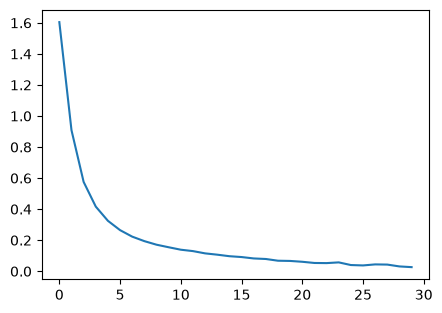

Early stopping in epoch 37 (best val_loss=0.163)


In [6]:
# RETURN:
# loss_sum = loss average in all batches
# accuracy of the model
def evaluate(model, data_val):
	model.eval()
	correct, total_samples, loss_sum = 0, 0, 0.0
	with torch.no_grad():
		for x, lengths, y in data_val:
			x, y = x.to(device), y.to(device)
			out = model(x, lengths)
			loss_sum += f_loss(out, y).item()
			# Get the higher value of 8 predictions
			preds = out.argmax(dim=1)
			# Compare predictions with real label, counts corrects in a batch
			correct += (preds == y).sum().item()
			total_samples += y.size(0)
	model.train()
	return loss_sum / len(data_val), correct / total_samples

model.train()
loss_history = []

best_val_loss = float('inf')
max_epoch = 15
count_epoch = 0

for epoch in range(200):
	epoch_loss = 0.0
	for batch_x, batch_lengths, batch_y in train_loader:
		batch_x = batch_x.to(device)
		batch_y = batch_y.to(device)
		error = train(model, batch_x, batch_lengths, batch_y, f_loss, optimizer)
		epoch_loss += error

	avg_loss = epoch_loss / len(train_loader)
	loss_history.append(avg_loss)

	val_loss, val_acc = evaluate(model, val_loader)

	# Early stoppig, if val_loss doesn't improve in 15 epochs
	if val_loss < best_val_loss:
		best_val_loss = val_loss
		count_epoch = 0
		torch.save(model.state_dict(), 'model_trained.pth')
	else:
		count_epoch += 1

	if (epoch + 1) % 10 == 0 or epoch == 199:
		clear_output(wait=True)
		print(f"Epoch {epoch+1}: train_loss={avg_loss:.3f}  val_loss={val_loss:.3f}  val_acc={val_acc:.2%}")
		plt.figure(figsize=(5, 3.5))
		plt.plot(loss_history)
		plt.show()

	if count_epoch >= max_epoch:
		print(f"Early stopping in epoch {epoch+1} (best val_loss={best_val_loss:.3f})")
		break

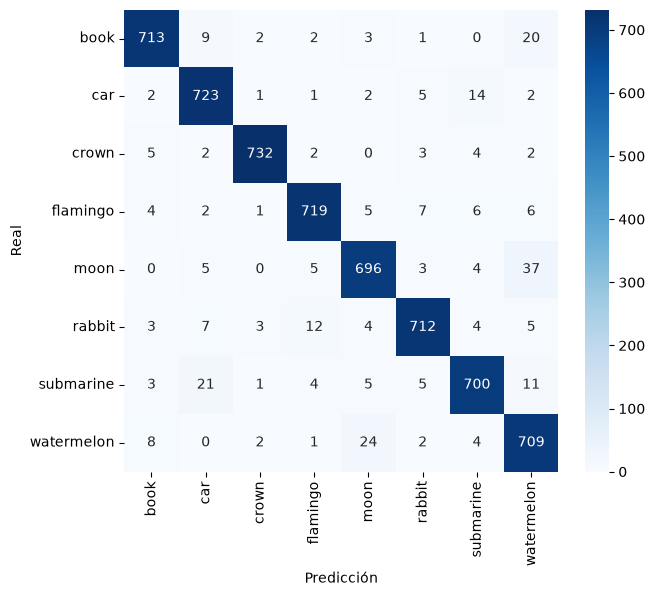

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for x, lengths, y in val_loader:
        x = x.to(device)
        preds = model(x, lengths).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(y.tolist())

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()